<a href="https://colab.research.google.com/github/kayjew/ENPH353_Lab6/blob/main/ENPH353_Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import string
import random
from random import randint
import cv2
import numpy as np
import os
from PIL import Image, ImageFont, ImageDraw

# Generate perfect images

In [2]:
# Run this command only once:

# makes the output folder /content/pictures/
!mkdir pictures

In [3]:
# Run this command only once

# Downloads the license plate template to /content/blank_plate.png
!gdown 1Q_FsX2z6DaDCLM91qGZzwvctaW9bN60v

Downloading...
From: https://drive.google.com/uc?id=1Q_FsX2z6DaDCLM91qGZzwvctaW9bN60v
To: /content/blank_plate.png
100% 144k/144k [00:00<00:00, 4.84MB/s]


In [4]:
path = "/content/"

NUMBER_OF_PLATES = 200

# Generate NUMBER_OF_PLATES with random values of the form CC NN (C: character
# N: number)

for i in range(0, NUMBER_OF_PLATES):

    # Pick two random letters
    plate_alpha = ""
    for _ in range(0, 2):
        plate_alpha += (random.choice(string.ascii_uppercase))

    # Pick two random numbers
    num = randint(0, 99)
    plate_num = "{:02d}".format(num)

    # Write plate to image
    blank_plate = cv2.imread(path+'blank_plate.png')

    # Convert into a PIL image (this is so we can use the monospaced fonts)
    blank_plate_pil = Image.fromarray(blank_plate)

    # Get a drawing context
    draw = ImageDraw.Draw(blank_plate_pil)
    monospace = ImageFont.truetype(font="/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf",
                                   size=165)
    draw.text(xy=(48, 75),
              text=plate_alpha + " " + plate_num,
              fill=(255,0,0), font=monospace)

    # Convert back to OpenCV image and save
    blank_plate = np.array(blank_plate_pil)

    # Write license plate to file
    cv2.imwrite(os.path.join(path + "pictures/",
                             "plate_{}{}.png".format(plate_alpha, plate_num)),
                             blank_plate)

# Download and uncompress test set

In [5]:
!gdown 18TBwgykqhpCoyn6Sf6lV_-MplhIP9R5d
!unzip /content/test_pictures.zip

Downloading...
From: https://drive.google.com/uc?id=18TBwgykqhpCoyn6Sf6lV_-MplhIP9R5d
To: /content/test_pictures.zip
100% 16.6M/16.6M [00:00<00:00, 55.6MB/s]
Archive:  /content/test_pictures.zip
   creating: test_pictures/
  inflating: test_pictures/plate_AR20.png  
  inflating: test_pictures/plate_AT48.png  
  inflating: test_pictures/plate_AX07.png  
  inflating: test_pictures/plate_BJ61.png  
  inflating: test_pictures/plate_BR26.png  
  inflating: test_pictures/plate_BR36.png  
  inflating: test_pictures/plate_BT43.png  
  inflating: test_pictures/plate_BY61.png  
  inflating: test_pictures/plate_CC68.png  
  inflating: test_pictures/plate_CS82.png  
  inflating: test_pictures/plate_CU90.png  
  inflating: test_pictures/plate_CV48.png  
  inflating: test_pictures/plate_CW47.png  
  inflating: test_pictures/plate_DY60.png  
  inflating: test_pictures/plate_EP68.png  
  inflating: test_pictures/plate_ER19.png  
  inflating: test_pictures/plate_ER61.png  
  inflating: test_pictures/pl

# Example of Data Generator

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np

In [7]:
datagen = ImageDataGenerator(rotation_range=3, zoom_range=0.01,
                             brightness_range=[0.4, 1.0])
NUM_IMAGES_TO_GENERATE = 1
!mkdir /content/imperfect_plates

In [8]:
for root, dir, filenames in os.walk('/content/pictures/'):
  for filename in filenames:
    # Load image:
    image_path = '/content/pictures/'+filename

    # Create an array with a single image (we need it for the iterator)
    image_array = np.expand_dims(Image.open(image_path), 0)

    datagen_iterator = datagen.flow(image_array, batch_size=1)

    for j in range(NUM_IMAGES_TO_GENERATE):
      value = next(datagen_iterator)
      img = value[0].astype('uint8')

      # process image to save path
      img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

      new_filename = f"aug_{j}_{filename}"
      save_path = os.path.join('/content/imperfect_plates/', new_filename)

      cv2.imwrite(save_path, img_bgr)

In [9]:
CHAR_LIST = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
             'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
             'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
             'U', 'V', 'W', 'X', 'Y', 'Z']
IMG_HEIGHT, IMG_WIDTH = 128, 64
input_dir = '/content/imperfect_plates'

base_dir = '/content/train_data'
os.makedirs(base_dir, exist_ok=True)
for char in CHAR_LIST:
    os.makedirs(os.path.join(base_dir, char), exist_ok=True)


# define crop coordinates [y1:y2, x1:x2]
def crop_characters(img)
    c1 = img[70:250, 45:145]
    c2 = img[70:250, 145:245]
    n1 = img[70:250, 350:450]
    n2 = img[70:250, 450:550]

    return [c1, c2, n1, n2]

for root, dir, filenames in os.walk(input_dir):
  for filename in filenames:
      # extract plate number
      label_str = filename.split('_')[-1].split('.')[0].replace('plate', '')

      img = cv2.imread(os.path.join(input_dir, filename))
      if img is None: continue

      crop = crop_characters(img)

      #write to save_path
      for i in range(4):
          char_crop = cv2.resize(crop[i], (IMG_WIDTH, IMG_HEIGHT))
          save_path = os.path.join(base_dir, label_str[i], f"{i}_{filename}")
          cv2.imwrite(save_path, char_crop)

In [10]:
# normalize data using hot ones
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=32,
    class_mode='categorical',
    subset='training')

validation_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=32,
    class_mode='categorical',
    subset='validation')

Found 649 images belonging to 36 classes.
Found 147 images belonging to 36 classes.


In [11]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers

def reset_weights(model):
  for ix, layer in enumerate(model.layers):
      if (hasattr(model.layers[ix], 'kernel_initializer') and
          hasattr(model.layers[ix], 'bias_initializer')):
          weight_initializer = model.layers[ix].kernel_initializer
          bias_initializer = model.layers[ix].bias_initializer

          old_weights, old_biases = model.layers[ix].get_weights()

          model.layers[ix].set_weights([
              weight_initializer(shape=old_weights.shape),
              bias_initializer(shape=len(old_biases))])

conv_model = models.Sequential()
conv_model.add(layers.Conv2D(32, (3, 3), activation='relu',
                             input_shape=(128, 64, 3)))
conv_model.add(layers.MaxPooling2D((2, 2)))
conv_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
conv_model.add(layers.MaxPooling2D((2, 2)))
conv_model.add(layers.Conv2D(128, (3, 3), activation='relu'))
conv_model.add(layers.MaxPooling2D((2, 2)))
conv_model.add(layers.Conv2D(128, (3, 3), activation='relu'))
conv_model.add(layers.MaxPooling2D((2, 2)))

conv_model.add(layers.Flatten())
conv_model.add(layers.Dropout(0.5))
conv_model.add(layers.Dense(512, activation='relu'))
conv_model.add(layers.Dense(36, activation='softmax'))

LEARNING_RATE = 1e-4

conv_model.compile(loss='categorical_crossentropy',
                   optimizer=optimizers.RMSprop(learning_rate=LEARNING_RATE),
                   metrics=['acc'])
reset_weights(conv_model)

history_conv = conv_model.fit(
    train_generator,
    epochs=20,
    steps_per_epoch=len(train_generator),
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - acc: 0.0447 - loss: 3.5507 - val_acc: 0.0612 - val_loss: 3.4925
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.0570 - loss: 3.4774 - val_acc: 0.1156 - val_loss: 3.4385
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - acc: 0.0801 - loss: 3.4484 - val_acc: 0.1293 - val_loss: 3.3942
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.1017 - loss: 3.4086 - val_acc: 0.1293 - val_loss: 3.3221
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.1156 - loss: 3.3262 - val_acc: 0.1837 - val_loss: 3.1855
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - acc: 0.1633 - loss: 3.1705 - val_acc: 0.2653 - val_loss: 2.9210
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - acc: 0.2527 - loss: 2.8842 - val_acc: 0.4014 - val_loss: 2.4713
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - acc: 0.3636 - loss: 2.4509 - val_acc: 0.6190 - val_loss: 1.8790
Epoch 9/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - acc: 0.48

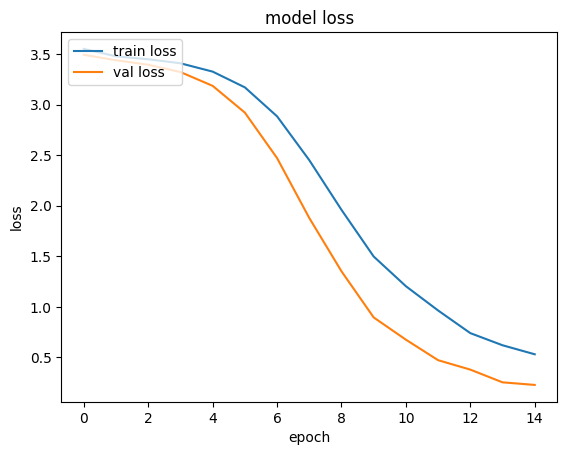

Final train acc: 0.8197226524353027
Final val acc: 0.9591836929321289


In [12]:
plt.plot(history_conv.history['loss'])
plt.plot(history_conv.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train loss', 'val loss'], loc='upper left')
plt.show()

print("Final train acc:", history_conv.history['acc'][-1])
print("Final val acc:", history_conv.history['val_acc'][-1])

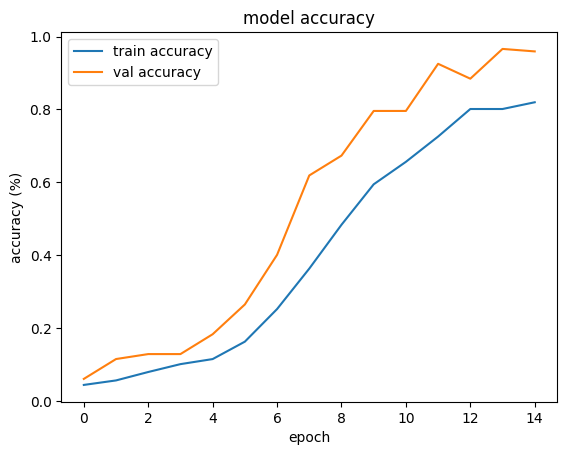

In [13]:
plt.plot(history_conv.history['acc'])
plt.plot(history_conv.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy (%)')
plt.xlabel('epoch')
plt.legend(['train accuracy', 'val accuracy'], loc='upper left')
plt.show()

Evaluating Official Test Set...


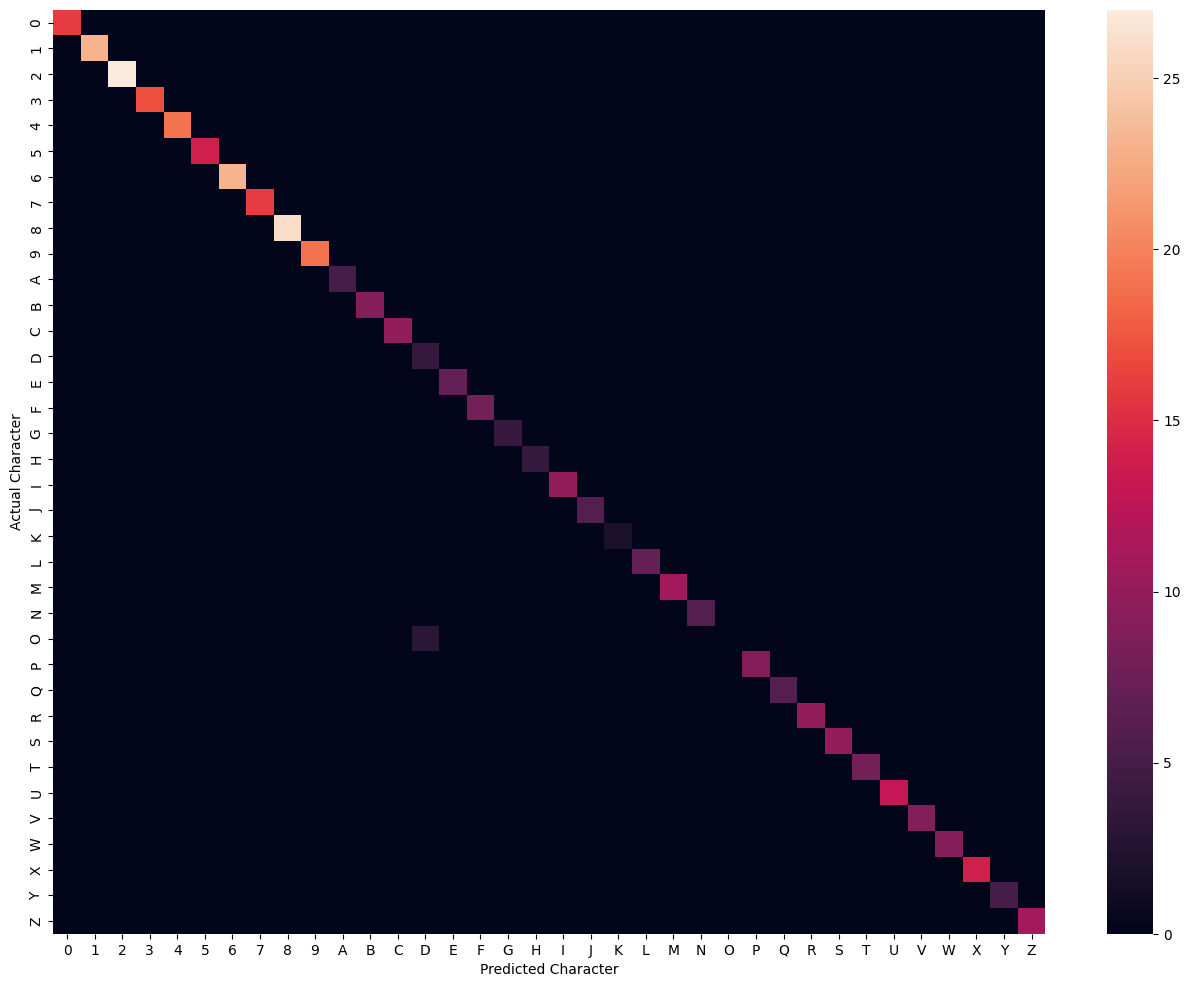

Final Test Set Accuracy: 99.25%


In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

#get mapping
class_indices = train_generator.class_indices
index_to_char = {v: k for k, v in class_indices.items()}

# make digit/letter index lists
digit_indices = [class_indices[str(d)] for d in range(10)]
letter_indices = [class_indices[c] for c in 'ABCDEFGHIJKLMNOPQRSTUVWXYZ']

y_true_test = []
y_pred_test = []

test_eval_dir = '/content/test_pictures'

print("Evaluating Official Test Set...")


for filename in os.listdir(test_eval_dir):
    if not filename.endswith(".png"):
        continue

    # extract plate number image
    label_str = filename.split('_')[-1].replace('.png', '').replace('plate', '')


    img_path = os.path.join(test_eval_dir, filename)
    img = cv2.imread(img_path)

    crops = crop_characters(img)

    #prep character images for NN
    for i in range(4):
        char_img = cv2.resize(crops[i], (IMG_WIDTH, IMG_HEIGHT))

        char_img = cv2.cvtColor(char_img, cv2.COLOR_BGR2RGB)
        char_img = char_img.astype('float32') / 255.0
        char_img = np.expand_dims(char_img, axis=0)

        preds = conv_model.predict(char_img, verbose=0)[0]

        # make a prediction using digit vs letter index depending on location
        if i < 2:
            # letters
            subset = preds[letter_indices]
            pred_idx = letter_indices[np.argmax(subset)]
        else:
            # digits
            subset = preds[digit_indices]
            pred_idx = digit_indices[np.argmax(subset)]

        # true character/digit
        true_char = label_str[i]
        true_idx = class_indices[true_char]

        y_true_test.append(true_idx)
        y_pred_test.append(pred_idx)

#plot the confusion matrix
num_classes = len(class_indices)

labels_sorted = [index_to_char[i] for i in range(num_classes)]

cm = confusion_matrix(y_true_test, y_pred_test, labels=range(num_classes))

plt.figure(figsize=(16, 12))
sns.heatmap(cm,xticklabels=labels_sorted,yticklabels=labels_sorted)

plt.xlabel('Pred')
plt.ylabel('True')
plt.show()

# calc accuracy
final_acc = np.mean(np.array(y_true_test) == np.array(y_pred_test))
print(f"Final Test Set Accuracy: {final_acc * 100:.2f}%")